In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

sys.path.append("/pfs/work9/workspace/scratch/ma_faroesch-master-thesis/playground-uc3/master-thesis")
from cbm_datasets import CUB_112, CUB_312, get_transform_cub  # Import anpassen

In [2]:
from architecture.upsampler_modules import get_upsampler_by_name
from architecture.extended_cbm import get_dinov3_timm

In [3]:
# Pfade anpassen!
device = "cpu"
ROOT_DIR = "/pfs/work9/workspace/scratch/ma_faroesch-master-thesis/datasets/CUB_200_2011"

# Transform ohne Crop für Masken-Generierung ist oft sicherer,
# aber wenn du später auf gecroppten Bildern trainierst, MUSST du hier 
# exakt denselben Transform (Crop/Resize) nutzen wie im Training!
transform = get_transform_cub(img_size=256, center_crop_size=None) # oder mit Crop

dataset = CUB_312(root_dir=ROOT_DIR, mode="train", transform=transform, concept_masks_scale=None) # Modus egal wenn du alles willst

In [4]:
# Example
bird = dataset[130]
bird.keys()

dict_keys(['class_idx', 'image_id', 'image', 'concepts', 'concept_coords', 'concept_point_mask', 'labels', 'mask_foreground'])

In [5]:
anyup = get_upsampler_by_name("anyup").to(device)
backbone = get_dinov3_timm().to(device)

Using cache found in /pfs/work9/workspace/scratch/ma_faroesch-master-thesis/.cache/hub/wimmerth_anyup_main


In [6]:
image = torch.Tensor(bird["image"]).unsqueeze(0).to(device)  # Add batch dimension

# normalize image with imagenet mean and std
mean = torch.Tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(device)
std = torch.Tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(device)

image_unnormalized = (image - mean) / std

In [7]:
f_lr = backbone(image.to(device))[0]

In [8]:
f_hr = anyup(image, f_lr)

In [9]:
from torch.nn import functional as F

x = 100
y = 100

# calculate cosine similarity map between position (x, y) and all other positions in f
def cosine_similarity_map(f, x, y, normalize = False):
    
    # Normalize feature map along channel dimension
    if normalize:
        f = f - f.mean(dim=(2,3), keepdim=True)
    
    f_norm = F.normalize(f, dim=1)

    # Get the feature vector at (x, y)
    f_vector = f_norm[:, :, y, x].unsqueeze(-1).unsqueeze(-1)  # Shape: (1, C, 1, 1)

    # Compute cosine similarity
    sim_map = torch.sum(f_norm * f_vector, dim=1)  # Shape: (1, H, W)

    return sim_map.squeeze(0).cpu().detach().numpy()  # Remove batch dimension and move to CPU

In [10]:
def plot_sim_maps_with_thresholds(
    gt_mask,
    sim_map,
    thresholded_maps,
    x=None,
    y=None,
    thresholds=None,
    cmap_sim="hot",
    cmap_gt="gray",
    alpha_gt=0.3,
    alpha_thresh=0.7,
    figsize=(4, 4),
):

    n_thresh = len(thresholded_maps)
    n_cols = 2 + n_thresh

    fig, axes = plt.subplots(
        1, n_cols, figsize=(figsize[0] * n_cols, figsize[1])
    )

    # ---------- GT ----------
    ax = axes[0]
    ax.imshow(gt_mask, cmap=cmap_gt)
    ax.set_title("GT")
    ax.axis("off")

    if x is not None and y is not None:
        ax.plot(x, y, "r+", markersize=12)

    # ---------- Similarity map ----------
    ax = axes[1]
    im = ax.imshow(sim_map, cmap=cmap_sim)
    ax.set_title("Similarity Map")
    ax.axis("off")

    if x is not None and y is not None:
        ax.plot(x, y, "r+", markersize=12)

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # ---------- Thresholded maps with GT overlay ----------
    for i, th_map in enumerate(thresholded_maps):
        ax = axes[2 + i]

        # GT in background
        ax.imshow(gt_mask, cmap=cmap_gt, alpha=alpha_gt)

        # Thresholded similarity map on top
        ax.imshow(th_map, cmap=cmap_sim, alpha=alpha_thresh)

        ax.axis("off")

        title = "Thresholded"
        if thresholds is not None:
            title += f"\n(t={thresholds[i]:.2f})"
        ax.set_title(title)

        if x is not None and y is not None:
            ax.plot(x, y, "r+", markersize=12)

    plt.tight_layout()
    plt.show()


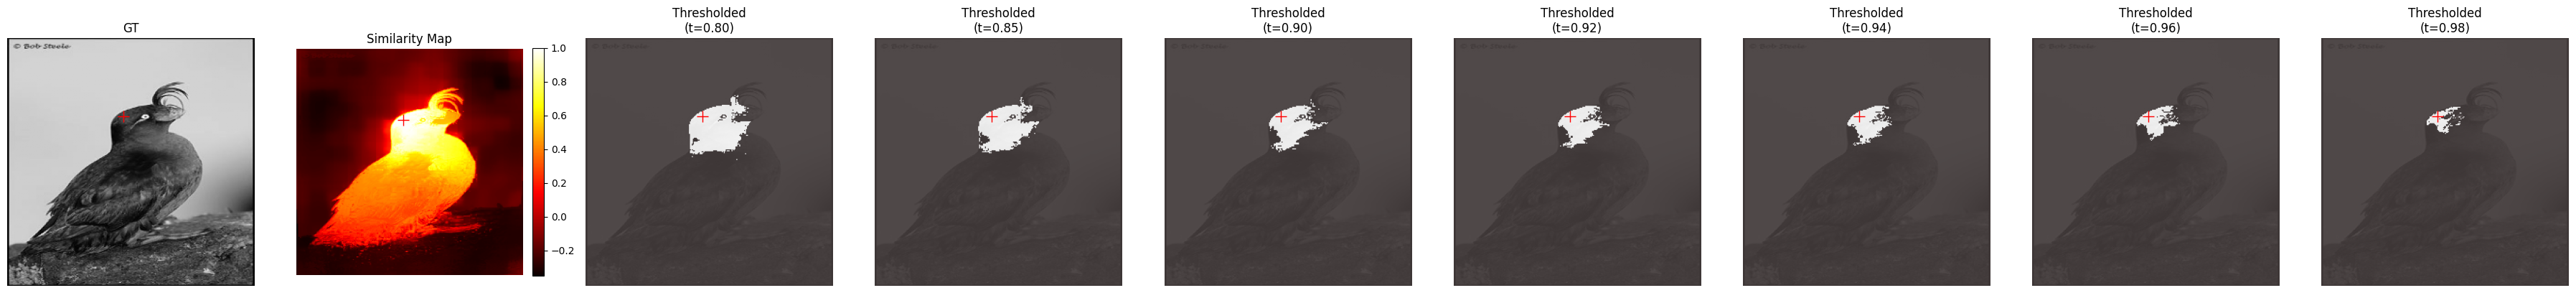

In [11]:
x = 120
y = 80

sim_matrix = cosine_similarity_map(f_hr, x=x, y=y, normalize=True)  # Beispiel für Punkt (x, y) in f_hr
thresholds = [0.80, 0.85, 0.9, 0.92, 0.94, 0.96, 0.98]
thresholded_maps = [(sim_matrix > t).astype(float) for t in thresholds]


plot_sim_maps_with_thresholds(
    gt_mask=image_unnormalized.squeeze(0).cpu().numpy().mean(axis=0),  # Convert to H, W
    sim_map=sim_matrix,
    thresholded_maps=thresholded_maps,
    thresholds=thresholds,
    x=x,
    y=y,
)

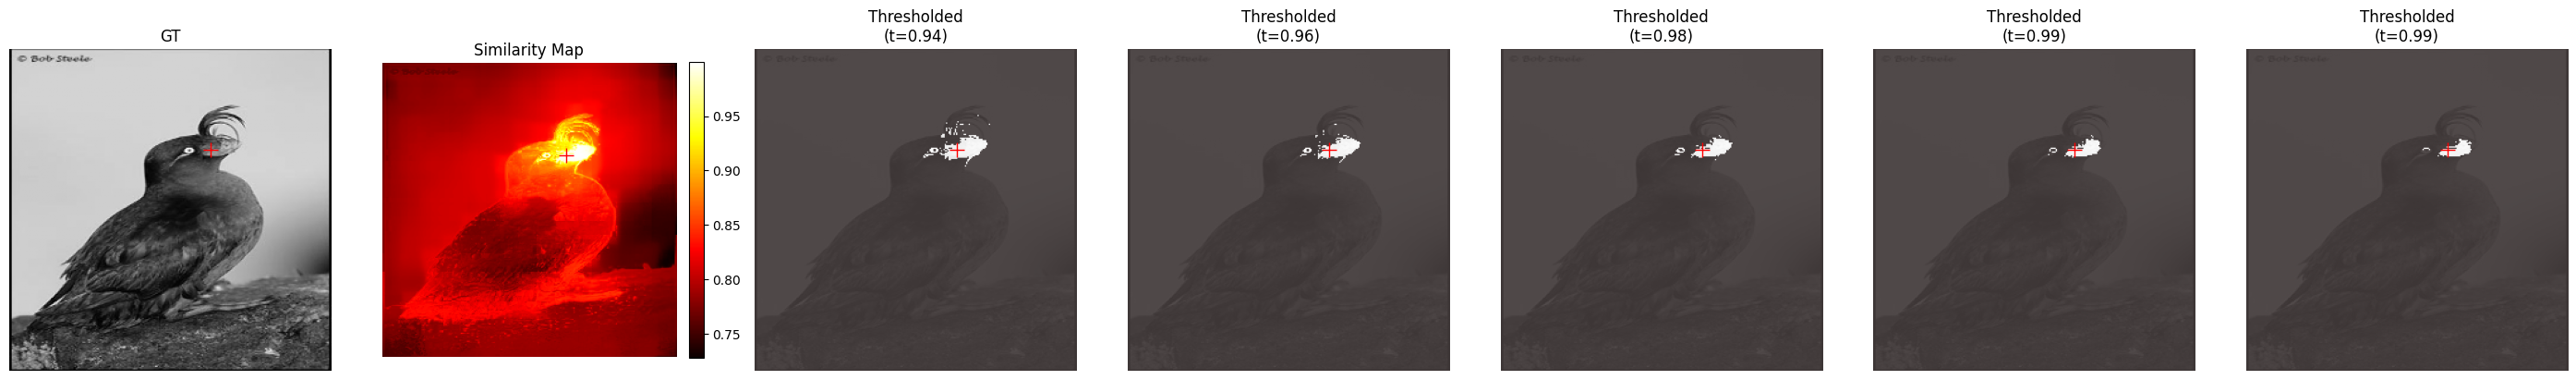

In [19]:
x = 160
y = 80

sim_matrix = cosine_similarity_map(f_hr, x=x, y=y, normalize=False)  # Beispiel für Punkt (x, y) in f_hr
thresholds = [0.94, 0.96, 0.98, 0.99, 0.995]
thresholded_maps = [(sim_matrix > t).astype(float) for t in thresholds]


plot_sim_maps_with_thresholds(
    gt_mask=image_unnormalized.squeeze(0).cpu().numpy().mean(axis=0),  # Convert to H, W
    sim_map=sim_matrix,
    thresholded_maps=thresholded_maps,
    thresholds=thresholds,
    x=x,
    y=y,
)